In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data_py = {
    "n": [100, 500, 1000, 5000, 10000, 50000],
    "media_py": [0.000086, 0.000662, 0.001574, 0.010286, 0.023132, 0.162804],
    "desvio_py": [0.000006, 0.000022, 0.000051, 0.000235, 0.000683, 0.003748],
}

data_c = {
    "n": [100, 500, 1000, 5000, 10000, 50000],
    "media_c": [0.000007, 0.000048, 0.000109, 0.000667, 0.001536, 0.009024],
    "desvio_c": [0.000001, 0.000001, 0.000007, 0.000025, 0.000084, 0.000118],
}

df_py = pd.DataFrame(data_py)
df_c = pd.DataFrame(data_c)

df = pd.merge(df_py, df_c, on="n")

df["n_log_n"] = df["n"] * np.log2(df["n"])

df["tempo_py_norm"] = df["media_py"] / df["media_py"].max()
df["tempo_c_norm"] = df["media_c"] / df["media_c"].max()
df["n_log_n_norm"] = df["n_log_n"] / df["n_log_n"].max()

df["speedup_python_vs_c"] = df["media_py"] / df["media_c"]

df



,n,media_py,desvio_py,media_c,desvio_c,n_log_n,tempo_py_norm,tempo_c_norm,n_log_n_norm,speedup_python_vs_c
0,100,0.000086,0.000006,0.000007,0.000001,664.385619,0.000528,0.000776,0.000851,12.285714
1,500,0.000662,0.000022,0.000048,0.000001,4482.892142,0.004066,0.005319,0.005744,13.791667
2,1000,0.001574,0.000051,0.000109,0.000007,9965.784285,0.009668,0.012079,0.012769,14.440367
3,5000,0.010286,0.000235,0.000667,0.000025,61438.561898,0.063180,0.073914,0.078719,15.421289
4,10000,0.023132,0.000683,0.001536,0.000084,132877.123795,0.142085,0.170213,0.170250,15.059896
5,50000,0.162804,0.003748,0.009024,0.000118,780482.023722,1.000000,1.000000,1.000000,18.041223


In [ ]:
tabela_resumo = df[[
    "n",
    "media_py", "desvio_py",
    "media_c", "desvio_c",
    "speedup_python_vs_c"
]]

tabela_resumo

,n,media_py,desvio_py,media_c,desvio_c,speedup_python_vs_c
0,100,0.000086,0.000006,0.000007,0.000001,12.285714
1,500,0.000662,0.000022,0.000048,0.000001,13.791667
2,1000,0.001574,0.000051,0.000109,0.000007,14.440367
3,5000,0.010286,0.000235,0.000667,0.000025,15.421289
4,10000,0.023132,0.000683,0.001536,0.000084,15.059896
5,50000,0.162804,0.003748,0.009024,0.000118,18.041223


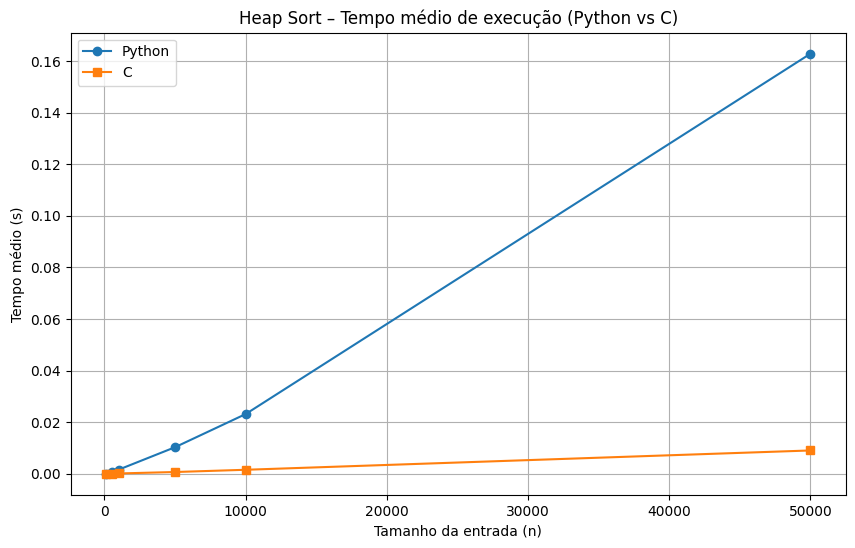

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df["n"], df["media_py"], marker="o", label="Python")
plt.plot(df["n"], df["media_c"], marker="s", label="C")

plt.xlabel("Tamanho da entrada (n)")
plt.ylabel("Tempo médio (s)")
plt.title("Heap Sort – Tempo médio de execução (Python vs C)")
plt.grid(True)
plt.legend()
plt.show()

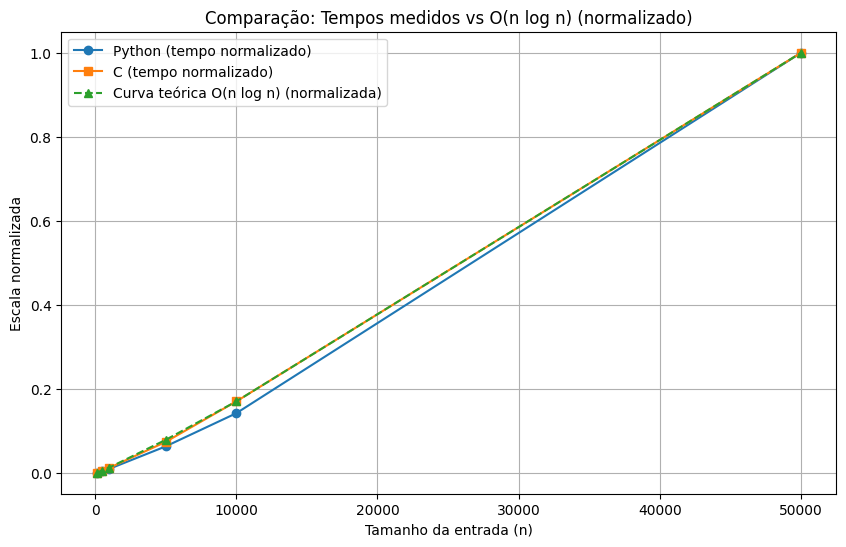

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(df["n"], df["tempo_py_norm"], marker="o", label="Python (tempo normalizado)")
plt.plot(df["n"], df["tempo_c_norm"], marker="s", label="C (tempo normalizado)")
plt.plot(df["n"], df["n_log_n_norm"], marker="^", linestyle="--", label="Curva teórica O(n log n) (normalizada)")

plt.xlabel("Tamanho da entrada (n)")
plt.ylabel("Escala normalizada")
plt.title("Comparação: Tempos medidos vs O(n log n) (normalizado)")
plt.grid(True)
plt.legend()
plt.show()


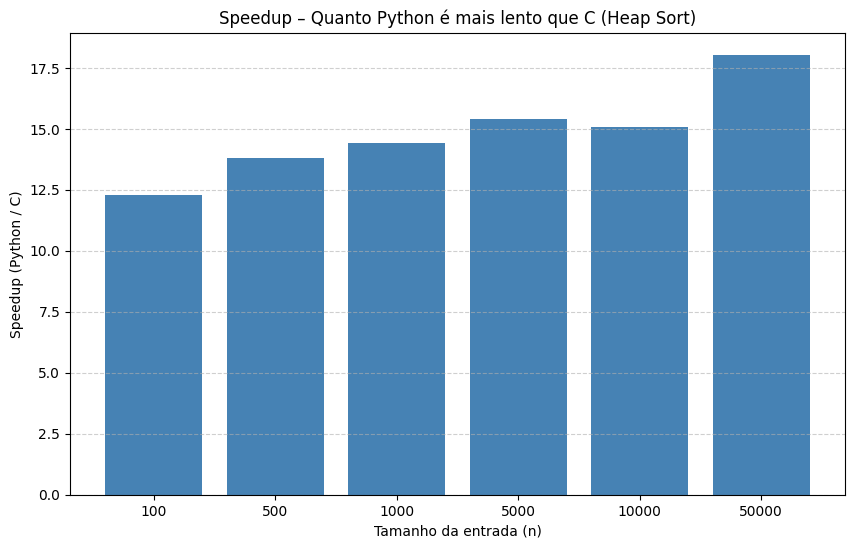

In [ ]:
plt.figure(figsize=(10, 6))

# Converte n para strings para virar eixo categórico
x_labels = df["n"].astype(str)

plt.bar(x_labels, df["speedup_python_vs_c"], color="steelblue")

plt.xlabel("Tamanho da entrada (n)")
plt.ylabel("Speedup (Python / C)")
plt.title("Speedup – Quanto Python é mais lento que C (Heap Sort)")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()



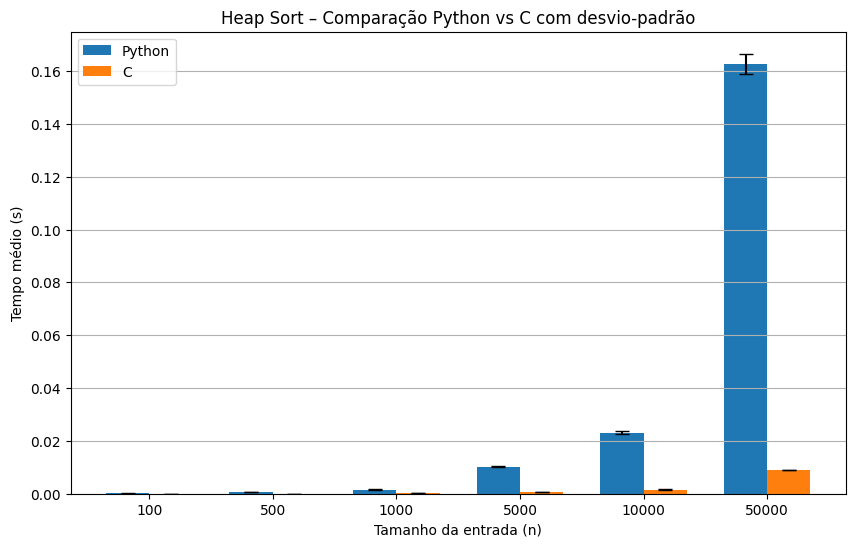

In [ ]:
x = np.arange(len(df["n"]))  # posições (0, 1, 2, ...)
width = 0.35                 # largura das barras

plt.figure(figsize=(10, 6))

# Barras para Python com desvio-padrão
plt.bar(
    x - width/2,
    df["media_py"],
    width,
    yerr=df["desvio_py"],
    capsize=5,
    label="Python"
)

# Barras para C com desvio-padrão
plt.bar(
    x + width/2,
    df["media_c"],
    width,
    yerr=df["desvio_c"],
    capsize=5,
    label="C"
)

plt.xticks(x, df["n"])
plt.xlabel("Tamanho da entrada (n)")
plt.ylabel("Tempo médio (s)")
plt.title("Heap Sort – Comparação Python vs C com desvio-padrão")
plt.grid(axis="y")
plt.legend()
plt.show()

